1. 데이터셋 불러와서 학습 준비

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split



In [2]:
from sklearn.datasets import fetch_california_housing

# X, y 분리
california = fetch_california_housing(as_frame=True)
df = california.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [3]:
X = df.drop("MedHouseVal", axis=1)
y = df['MedHouseVal']

print(X.shape, y.shape) # (20640, 8) (20640, 1)

(20640, 8) (20640,)


In [4]:
# 학습데이터와 테스트 데이터 분리 (학습 80%, 테스트 20%, random_state=42)
# 회귀
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(len(X_train),len(X_test),len(y_train),len(y_test))

16512 4128 16512 4128


In [5]:
# StandardScaler 정규화 (학습데이터는 학습/변환, 테스트데이터는 변환)
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

ndarray 형태인 X_train_scaled를 DataFrame형식으로 재구성

In [6]:
# 스케일링된
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns= X_train.columns,
    index= X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns= X_test.columns,
    index= X_test.index
)

In [7]:
X_train_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
14265,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
2271,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551
...,...,...,...,...,...,...,...,...
11284,1.307215,0.507194,0.290620,-0.393391,-0.675847,-0.005588,-0.872016,0.808883
11964,-0.436266,0.348490,0.600411,0.398898,0.287195,0.069722,-0.759688,1.073144
5390,-0.496973,0.586545,-0.606759,-0.039216,0.289833,0.020306,-0.755007,0.599469
860,0.965450,-1.079841,0.402175,-0.066265,0.308303,0.007076,0.906510,-1.185540


In [8]:
X_test_scaled

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20046,-1.155085,-0.286324,-0.520686,-0.171746,-0.030301,0.067408,0.195100,0.285347
3024,-0.708659,0.110435,-0.165815,0.223472,0.121851,-0.036030,-0.235491,0.060975
15663,-0.210402,1.856173,-0.610765,0.205892,-0.102419,-0.149989,1.009478,-1.424870
20484,0.975113,-0.921138,0.305115,-0.176552,0.244979,0.030011,-0.637999,0.429943
9814,-0.081794,0.427842,0.024193,-0.158465,-0.319653,-0.052971,0.457199,-1.170581
...,...,...,...,...,...,...,...,...
15362,0.380334,-1.000489,0.656380,-0.069975,-0.066360,-0.009330,-1.068590,1.177851
16623,-0.606098,-0.048268,0.291827,0.369465,0.196607,-0.065340,-0.132523,-0.622115
18086,2.809024,-0.286324,0.755012,-0.345109,0.139441,-0.026469,0.780141,-1.230414
2144,-0.575430,0.586545,-0.061243,-0.262147,-0.175417,-0.043905,0.527404,-0.088607


2. PyTorch를 사용한 모델 학습

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
X_train_tensor = torch.from_numpy(X_train_scaled.to_numpy()).float() # train데이터 FloatTensor 변환
X_test_tensor = torch.from_numpy(X_test_scaled.to_numpy()).float()   # test데이터 FloatTensor 변환

# (샘플 수, 1) 형태로 변환시켜 학습에 사용
y_train_tensor =  torch.from_numpy(y_train.values).float().reshape(-1,1)
# (샘플 수, 1) 형태로 변환시켜 테스트에 사용
y_test_tensor =  torch.from_numpy(y_test.values).float().reshape(-1,1)
print(X_train_tensor.size(),X_test_tensor.size(),y_train_tensor.size(),y_test_tensor.size())

torch.Size([16512, 8]) torch.Size([4128, 8]) torch.Size([16512, 1]) torch.Size([4128, 1])


In [15]:
# 하이퍼파라미터 설정
n_epochs = 5000      # 학습 반복 횟수
learning_rate = 1e-3 # 학습률
print_interval = 500 # 로그 출력 간격

3. 모델 구축
- nn.Sequential을 사용
- 입력을 받아 64개 노드 은닉층
- 64개 노드 -> 64 은닉층
- 64개 노드 -> 32 은닉층
- 32개 노드 -> 출력층
- 활성화함수는 ReLU()

In [20]:
X_train_tensor.size()

torch.Size([16512, 8])

In [18]:
y_train_tensor.size()

torch.Size([16512, 1])

In [ ]:

model = nn.Sequential(
    nn.Linear(X_train_tensor.size(-1),64),
    nn.ReLU(),

    nn.Linear(64,64),
    nn.ReLU(),

    nn.Linear(64,32),
    nn.ReLU(),
    # 출력층
    nn.Linear(32, y_train_tensor.size(-1))
)
model

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): ReLU()
  (6): Linear(in_features=32, out_features=1, bias=True)
)

In [22]:
# Adam 최적화함수 : 모멘텀 + RMSProp을 결합한 최적화 알고리즘. 빠르고 안정적
optimizer = optim.Adam(
    model.parameters(), # 학습 대상 : 가중치, 편향 파라미터
    lr=learning_rate    # 학습률
)

In [ ]:
# CPU / GPU 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU 사용가능시 cuda, 불가시 cpu
model = model.to(device) # 모델 이동

In [24]:
# CPU / GPU로 데이터 이동
X_train = X_train_tensor.to(device)
y_train = y_train_tensor.to(device)
X_test = X_test_tensor.to(device)
y_test = y_test_tensor.to(device)


In [27]:
# 학습 루프
for epoch in range(n_epochs):
    model.train() # 학습 모드 (dropout, batchnorm 활성화 : 과적합 방지기법)

    y_hat = model(X_train)            # 순전파 : 모델 예측값 계산
    loss = F.mse_loss(y_hat, y_train) # 평균제곱오차(MSE) 손실 계산

    optimizer.zero_grad() # 기존 루프 기울기 초기화
    loss.backward()       # 역전파 : 손실을 기준으로  기울기 재계산

    optimizer.step()      # 파라미터 업데이트

    # 500번마다 학습손실 출력
    if (epoch + 1) % print_interval == 0:
        print(f"Epoch {epoch + 1}의 Train loss {loss.item():.4e}")

# 테스트
model.eval() # 평가 모드 (dropout, batchnorm 비활성화)
with torch.no_grad(): # 기울기 계산 비활성화
    y_pred_test = model(X_test) # 테스트 데이터 예측
    test_loss = F.mse_loss(y_pred_test, y_test) # 테스트 손실 계산
print(f"Test MSE: {test_loss.item():.4e}") # 테스트 MSE 출력

Epoch 500의 Train loss 1.7856e-01
Epoch 1000의 Train loss 1.7387e-01
Epoch 1500의 Train loss 1.7126e-01
Epoch 2000의 Train loss 1.6714e-01
Epoch 2500의 Train loss 1.6484e-01
Epoch 3000의 Train loss 1.6126e-01
Epoch 3500의 Train loss 1.5920e-01
Epoch 4000의 Train loss 1.5727e-01
Epoch 4500의 Train loss 1.5488e-01
Epoch 5000의 Train loss 1.5189e-01
Test MSE: 3.3372e-01


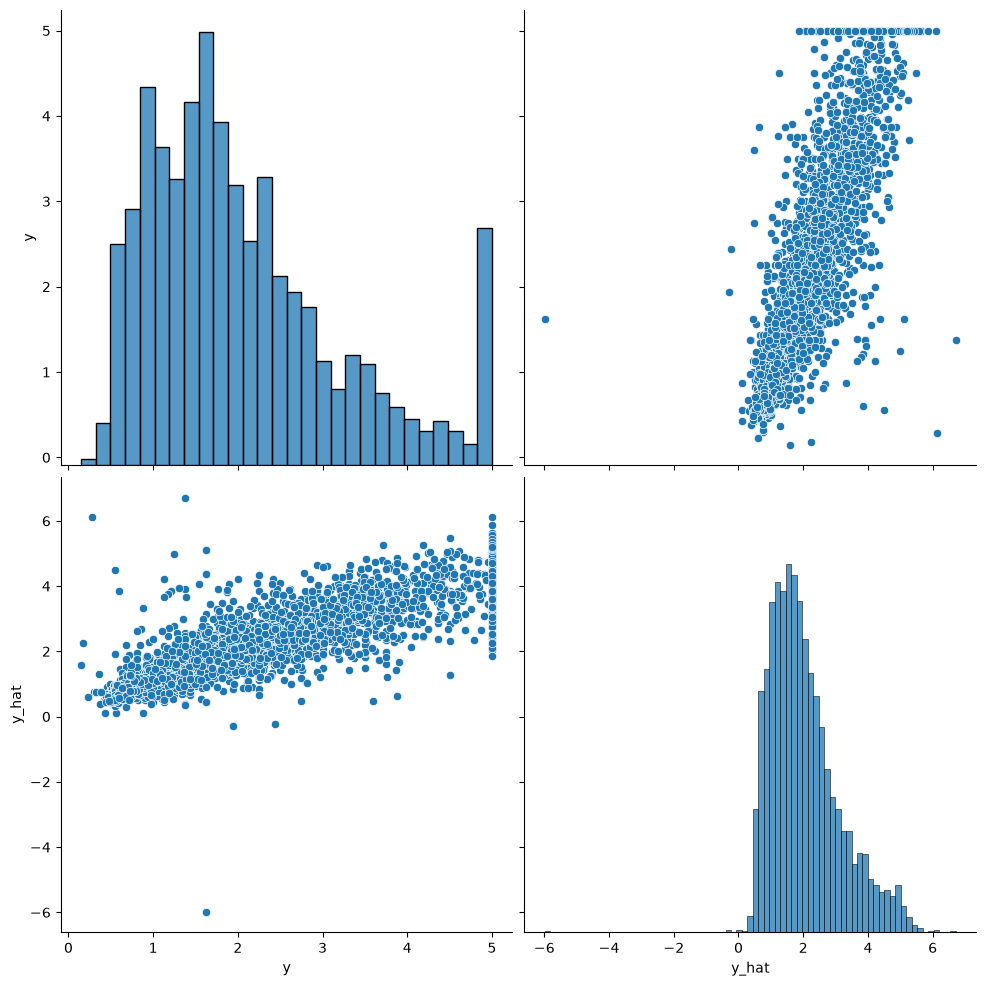

In [32]:
# GPU에서 학습한 모델, 데이터들을 다시 cpu로 가져와서 시각화
model.eval()
with torch.no_grad():
    y_pred = model(X_test).cpu().numpy().reshape(-1) # 예측값을 CPU -> Numpy -> 1차원 배열로 변환
    y_true = y_test.cpu().numpy().reshape(-1)        # 정답값을 CPU -> Numpy -> 1차원 배열로 변환
    df_result = pd.DataFrame({
        "y" : y_true,
        "y_hat" : y_pred
    })

    sns.pairplot(df_result, height=5)
    plt.show()